In [26]:
import pandas as pd
import numpy as np

from pathlib import Path

from sklearn.model_selection import (
    train_test_split,
    StratifiedGroupKFold
)

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [27]:
dataset_path = Path("../dataset/balanceDataset")

healthy_path = dataset_path / "Healthy"
pd_path = dataset_path / "PD"

healthy_files = list(healthy_path.glob("*.csv"))
pd_files = list(pd_path.glob("*.csv"))

# HC139 was excluded in the original pipeline
usable_healthy_files = [
    file for file in healthy_files
    if file.name != "HC139_Balance.csv"
]

usable_pd_files = pd_files.copy()

print("Healthy:", len(usable_healthy_files))
print("PD:", len(usable_pd_files))
print("Total recordings:", 
    len(usable_healthy_files) + len(usable_pd_files))

Healthy: 84
PD: 99
Total recordings: 183


In [28]:
balance_features = [
    "R_Wrist_Acc_X",
    "R_Wrist_Acc_Y",
    "R_Wrist_Acc_Z",
    "R_Wrist_Gyr_X",
    "R_Wrist_Gyr_Y",
    "R_Wrist_Gyr_Z"
]

In [29]:
def create_windows(df, window_size=500, min_valid_ratio=0.90):

    windows = []

    for start in range(
        0,
        len(df) - window_size + 1,
        window_size
    ):

        window = df.iloc[
            start:start + window_size
        ].copy()

        valid_ratio = (
            window[balance_features]
            .notna()
            .all(axis=1)
            .mean()
        )

        if valid_ratio >= min_valid_ratio:
            windows.append(window)

    return windows

In [30]:
def extract_window_feature(window):

    features = {}

    for col in balance_features:

        signal = window[col].dropna()

        features[f"{col}_mean"] = signal.mean()
        features[f"{col}_std"] = signal.std()
        features[f"{col}_min"] = signal.min()
        features[f"{col}_max"] = signal.max()
        features[f"{col}_rms"] = np.sqrt(
            np.mean(signal ** 2)
        )

    return features

In [31]:
def extract_dynamic_features(window):

    features = {}

    # ---------------------------------------------
    # Individual IMU channels
    # ---------------------------------------------

    for col in balance_features:

        signal = window[col].dropna().values

        if len(signal) < 2:
            continue

        diff = np.diff(signal)

        features[f"{col}_mean_abs_change"] = np.mean(
            np.abs(diff)
        )

        features[f"{col}_max_abs_change"] = np.max(
            np.abs(diff)
        )

        median = np.median(signal)

        features[f"{col}_mad"] = np.median(
            np.abs(signal - median)
        )

        centered = signal - np.mean(signal)

        zero_crossings = np.sum(
            centered[:-1] * centered[1:] < 0
        )

        features[f"{col}_zero_crossing_rate"] = (
            zero_crossings / (len(signal) - 1)
        )

    # ---------------------------------------------
    # Acceleration magnitude
    # ---------------------------------------------

    acc_x = window["R_Wrist_Acc_X"].dropna().values
    acc_y = window["R_Wrist_Acc_Y"].dropna().values
    acc_z = window["R_Wrist_Acc_Z"].dropna().values

    min_len = min(
        len(acc_x),
        len(acc_y),
        len(acc_z)
    )

    if min_len > 1:

        acc_x = acc_x[:min_len]
        acc_y = acc_y[:min_len]
        acc_z = acc_z[:min_len]

        acc_mag = np.sqrt(
            acc_x**2 +
            acc_y**2 +
            acc_z**2
        )

        acc_diff = np.diff(acc_mag)

        features["Acc_Magnitude_mean"] = np.mean(acc_mag)

        features["Acc_Magnitude_std"] = np.std(acc_mag)

        features["Acc_Magnitude_rms"] = np.sqrt(
            np.mean(acc_mag**2)
        )

        features["Acc_Magnitude_mean_abs_change"] = np.mean(
            np.abs(acc_diff)
        )

        features["Acc_Magnitude_max_abs_change"] = np.max(
            np.abs(acc_diff)
        )

        features["Acc_Magnitude_mad"] = np.median(
            np.abs(
                acc_mag - np.median(acc_mag)
            )
        )

    # ---------------------------------------------
    # Gyroscope magnitude
    # ---------------------------------------------

    gyr_x = window["R_Wrist_Gyr_X"].dropna().values
    gyr_y = window["R_Wrist_Gyr_Y"].dropna().values
    gyr_z = window["R_Wrist_Gyr_Z"].dropna().values

    min_len = min(
        len(gyr_x),
        len(gyr_y),
        len(gyr_z)
    )

    if min_len > 1:

        gyr_x = gyr_x[:min_len]
        gyr_y = gyr_y[:min_len]
        gyr_z = gyr_z[:min_len]

        gyr_mag = np.sqrt(
            gyr_x**2 +
            gyr_y**2 +
            gyr_z**2
        )

        gyr_diff = np.diff(gyr_mag)

        features["Gyr_Magnitude_mean"] = np.mean(gyr_mag)

        features["Gyr_Magnitude_std"] = np.std(gyr_mag)

        features["Gyr_Magnitude_rms"] = np.sqrt(
            np.mean(gyr_mag**2)
        )

        features["Gyr_Magnitude_mean_abs_change"] = np.mean(
            np.abs(gyr_diff)
        )

        features["Gyr_Magnitude_max_abs_change"] = np.max(
            np.abs(gyr_diff)
        )

        features["Gyr_Magnitude_mad"] = np.median(
            np.abs(
                gyr_mag - np.median(gyr_mag)
            )
        )

    return features

In [32]:
all_features = []

# ---------------------------------------------
# Healthy
# ---------------------------------------------

for file in usable_healthy_files:

    df = pd.read_csv(
        file,
        usecols=balance_features
    )

    windows = create_windows(
        df,
        window_size=500,
        min_valid_ratio=0.90
    )

    for window_id, window in enumerate(windows):

        basic = extract_window_feature(window)
        dynamic = extract_dynamic_features(window)

        features = {}

        features.update(basic)
        features.update(dynamic)

        features["recording_id"] = file.name
        features["window_id"] = window_id
        features["label"] = 0

        all_features.append(features)


# ---------------------------------------------
# PD
# ---------------------------------------------

for file in usable_pd_files:

    df = pd.read_csv(
        file,
        usecols=balance_features
    )

    windows = create_windows(
        df,
        window_size=500,
        min_valid_ratio=0.90
    )

    for window_id, window in enumerate(windows):

        basic = extract_window_feature(window)
        dynamic = extract_dynamic_features(window)

        features = {}

        features.update(basic)
        features.update(dynamic)

        features["recording_id"] = file.name
        features["window_id"] = window_id
        features["label"] = 1

        all_features.append(features)


v5_combined = pd.DataFrame(all_features)

print("V5 shape:", v5_combined.shape)
print("Recordings:", v5_combined["recording_id"].nunique())
print("NaN:", v5_combined.isna().sum().sum())

V5 shape: (5525, 69)
Recordings: 183
NaN: 0


In [33]:
v6_feature_cols = [

    # Acceleration statistical
    "R_Wrist_Acc_X_mean",
    "R_Wrist_Acc_X_std",
    "R_Wrist_Acc_X_min",
    "R_Wrist_Acc_X_max",
    "R_Wrist_Acc_X_rms",

    "R_Wrist_Acc_Y_mean",
    "R_Wrist_Acc_Y_std",
    "R_Wrist_Acc_Y_min",
    "R_Wrist_Acc_Y_max",
    "R_Wrist_Acc_Y_rms",

    "R_Wrist_Acc_Z_mean",
    "R_Wrist_Acc_Z_std",
    "R_Wrist_Acc_Z_min",
    "R_Wrist_Acc_Z_max",
    "R_Wrist_Acc_Z_rms",

    # Dynamic acceleration
    "R_Wrist_Acc_Y_mean_abs_change",
    "R_Wrist_Acc_Y_zero_crossing_rate",
    "R_Wrist_Acc_Z_mean_abs_change",

    # Acceleration magnitude
    "Acc_Magnitude_mean",
    "Acc_Magnitude_rms",
    "Acc_Magnitude_mean_abs_change"
]

print("V6 features:", len(v6_feature_cols))

V6 features: 21


In [34]:
v6_clean = v5_combined.dropna(
    subset=v6_feature_cols
).copy()

v6_clean = v6_clean[
    ~np.isinf(
        v6_clean[v6_feature_cols]
    ).any(axis=1)
].copy()

v6_clean.reset_index(drop=True, inplace=True)

print("V6 clean shape:", v6_clean.shape)
print("Recordings:", v6_clean["recording_id"].nunique())
print("NaN:", v6_clean[v6_feature_cols].isna().sum().sum())
print(
    "Inf:",
    np.isinf(v6_clean[v6_feature_cols]).sum().sum()
)

V6 clean shape: (5525, 69)
Recordings: 183
NaN: 0
Inf: 0


In [35]:
recording_ids = v6_clean["recording_id"].unique()

recording_labels = (
    v6_clean
    .groupby("recording_id")["label"]
    .first()
)

train_ids, test_ids = train_test_split(
    recording_ids,
    test_size=0.20,
    random_state=42,
    stratify=recording_labels
)

train_v6 = v6_clean[
    v6_clean["recording_id"].isin(train_ids)
].copy()

test_v6 = v6_clean[
    v6_clean["recording_id"].isin(test_ids)
].copy()

print("Train recordings:", len(train_ids))
print("Test recordings:", len(test_ids))

print("Train windows:", len(train_v6))
print("Test windows:", len(test_v6))

Train recordings: 146
Test recordings: 37
Train windows: 4384
Test windows: 1141


In [36]:
X_train_v6 = train_v6[v6_feature_cols]
y_train_v6 = train_v6["label"]

X_test_v6 = test_v6[v6_feature_cols]
y_test_v6 = test_v6["label"]

print("Train:", X_train_v6.shape)
print("Test :", X_test_v6.shape)

Train: (4384, 21)
Test : (1141, 21)


In [37]:
X_cv_v6 = train_v6[v6_feature_cols]
y_cv_v6 = train_v6["label"]
groups_v6 = train_v6["recording_id"]

cv_v6 = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

fold_scores_v6 = []

for fold, (train_idx, val_idx) in enumerate(
    cv_v6.split(
        X_cv_v6,
        y_cv_v6,
        groups=groups_v6
    ),
    start=1
):

    X_fold_train = X_cv_v6.iloc[train_idx]
    y_fold_train = y_cv_v6.iloc[train_idx]

    X_fold_val = X_cv_v6.iloc[val_idx]

    fold_val_df = train_v6.iloc[val_idx].copy()

    model_v6 = RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )

    model_v6.fit(
        X_fold_train,
        y_fold_train
    )

    val_pred = model_v6.predict(
        X_fold_val
    )

    fold_results = fold_val_df[
        ["recording_id", "label"]
    ].copy()

    fold_results["prediction"] = val_pred

    recording_fold = (
        fold_results
        .groupby("recording_id")
        .agg(
            actual_label=("label", "first"),
            pd_windows=("prediction", "sum"),
            total_windows=("prediction", "count")
        )
        .reset_index()
    )

    recording_fold["pd_ratio"] = (
        recording_fold["pd_windows"] /
        recording_fold["total_windows"]
    )

    recording_fold["final_prediction"] = (
        recording_fold["pd_ratio"] >= 0.5
    ).astype(int)

    score = accuracy_score(
        recording_fold["actual_label"],
        recording_fold["final_prediction"]
    )

    fold_scores_v6.append(score)

    print(
        f"V6 Fold {fold}: "
        f"{score:.4f} "
        f"({score * 100:.2f}%)"
    )

print("\nV6 Mean:", np.mean(fold_scores_v6))
print("V6 Std :", np.std(fold_scores_v6))

V6 Fold 1: 0.7241 (72.41%)
V6 Fold 2: 0.7241 (72.41%)
V6 Fold 3: 0.7333 (73.33%)
V6 Fold 4: 0.6552 (65.52%)
V6 Fold 5: 0.7241 (72.41%)

V6 Mean: 0.7121839080459769
V6 Std : 0.02872735512977161


In [38]:
final_model_v6 = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

final_model_v6.fit(
    X_train_v6,
    y_train_v6
)

test_pred_v6 = final_model_v6.predict(
    X_test_v6
)

In [39]:
test_results_v6 = test_v6[
    ["recording_id", "label"]
].copy()

test_results_v6["prediction"] = test_pred_v6

recording_results_v6 = (
    test_results_v6
    .groupby("recording_id")
    .agg(
        actual_label=("label", "first"),
        pd_windows=("prediction", "sum"),
        total_windows=("prediction", "count")
    )
    .reset_index()
)

recording_results_v6["pd_ratio"] = (
    recording_results_v6["pd_windows"] /
    recording_results_v6["total_windows"]
)

recording_results_v6["final_prediction"] = (
    recording_results_v6["pd_ratio"] >= 0.5
).astype(int)

In [40]:
print(
    "V6 Recording-level accuracy:",
    accuracy_score(
        recording_results_v6["actual_label"],
        recording_results_v6["final_prediction"]
    )
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        recording_results_v6["actual_label"],
        recording_results_v6["final_prediction"]
    )
)


V6 Recording-level accuracy: 0.6216216216216216

Confusion Matrix:
[[10  6]
 [ 8 13]]


In [41]:
v6_importance = pd.DataFrame({
    "feature": v6_feature_cols,
    "importance": final_model_v6.feature_importances_
}).sort_values(
    "importance",
    ascending=False
)

print(v6_importance)

                             feature  importance
18                Acc_Magnitude_mean    0.087006
19                 Acc_Magnitude_rms    0.071872
10                R_Wrist_Acc_Z_mean    0.064950
15     R_Wrist_Acc_Y_mean_abs_change    0.056618
9                  R_Wrist_Acc_Y_rms    0.054823
17     R_Wrist_Acc_Z_mean_abs_change    0.054535
5                 R_Wrist_Acc_Y_mean    0.048169
20     Acc_Magnitude_mean_abs_change    0.045890
12                 R_Wrist_Acc_Z_min    0.045692
14                 R_Wrist_Acc_Z_rms    0.044063
16  R_Wrist_Acc_Y_zero_crossing_rate    0.042183
13                 R_Wrist_Acc_Z_max    0.041303
0                 R_Wrist_Acc_X_mean    0.040733
7                  R_Wrist_Acc_Y_min    0.040209
4                  R_Wrist_Acc_X_rms    0.040044
3                  R_Wrist_Acc_X_max    0.039031
11                 R_Wrist_Acc_Z_std    0.038167
8                  R_Wrist_Acc_Y_max    0.036699
2                  R_Wrist_Acc_X_min    0.036632
6                  R

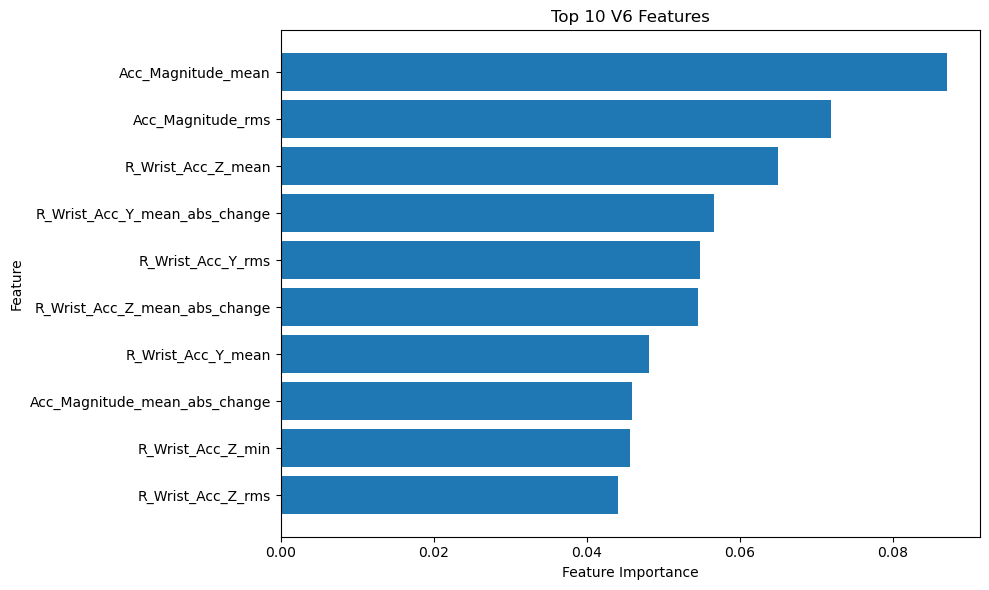

In [42]:
import matplotlib.pyplot as plt

top_features = v6_importance.head(10).sort_values(
    "importance"
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 10 V6 Features")

plt.tight_layout()
plt.show()

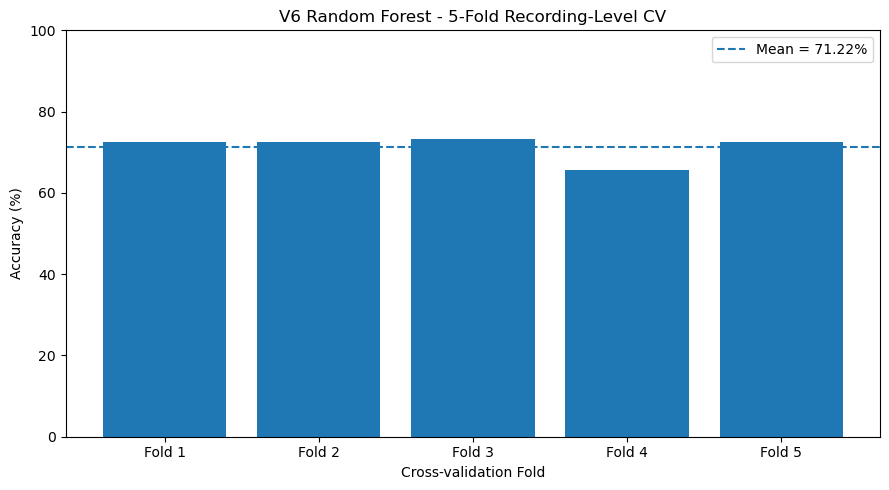

In [43]:
import matplotlib.pyplot as plt

cv_percent = [score * 100 for score in fold_scores_v6]

plt.figure(figsize=(9, 5))

bars = plt.bar(
    [f"Fold {i}" for i in range(1, 6)],
    cv_percent
)

plt.axhline(
    np.mean(cv_percent),
    linestyle="--",
    label=f"Mean = {np.mean(cv_percent):.2f}%"
)

plt.ylim(0, 100)

plt.ylabel("Accuracy (%)")
plt.xlabel("Cross-validation Fold")
plt.title("V6 Random Forest - 5-Fold Recording-Level CV")

plt.legend()
plt.tight_layout()

plt.savefig(
    "V6_CV_Accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

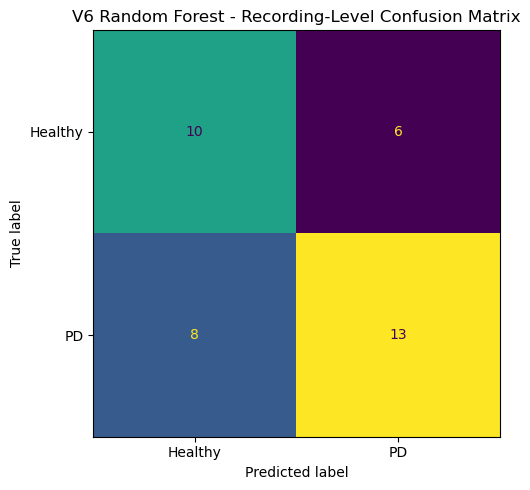

In [44]:
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(
    recording_results_v6["actual_label"],
    recording_results_v6["final_prediction"]
)

fig, ax = plt.subplots(figsize=(6, 5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Healthy", "PD"]
)

disp.plot(
    ax=ax,
    values_format="d",
    colorbar=False
)

plt.title(
    "V6 Random Forest - Recording-Level Confusion Matrix"
)

plt.tight_layout()

plt.savefig(
    "V6_Confusion_Matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [45]:
from sklearn.metrics import precision_score, recall_score, f1_score

y_true = recording_results_v6["actual_label"]
y_pred = recording_results_v6["final_prediction"]

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

metrics_table = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "Score": [
        accuracy,
        precision,
        recall,
        f1
    ]
})

metrics_table["Score"] = (
    metrics_table["Score"] * 100
).round(2)

metrics_table

,Metric,Score
0,Accuracy,62.16
1,Precision,68.42
2,Recall,61.90
3,F1 Score,65.00


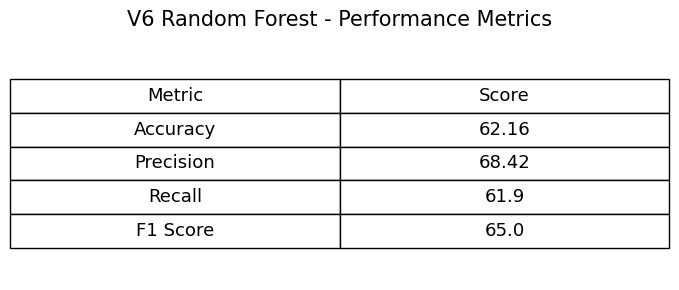

In [46]:
fig, ax = plt.subplots(figsize=(7, 3))

ax.axis("off")

table = ax.table(
    cellText=metrics_table.values,
    colLabels=metrics_table.columns,
    cellLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(13)
table.scale(1.3, 2)

plt.title(
    "V6 Random Forest - Performance Metrics",
    fontsize=15,
    pad=15
)

plt.tight_layout()

plt.savefig(
    "V6_Performance_Metrics.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

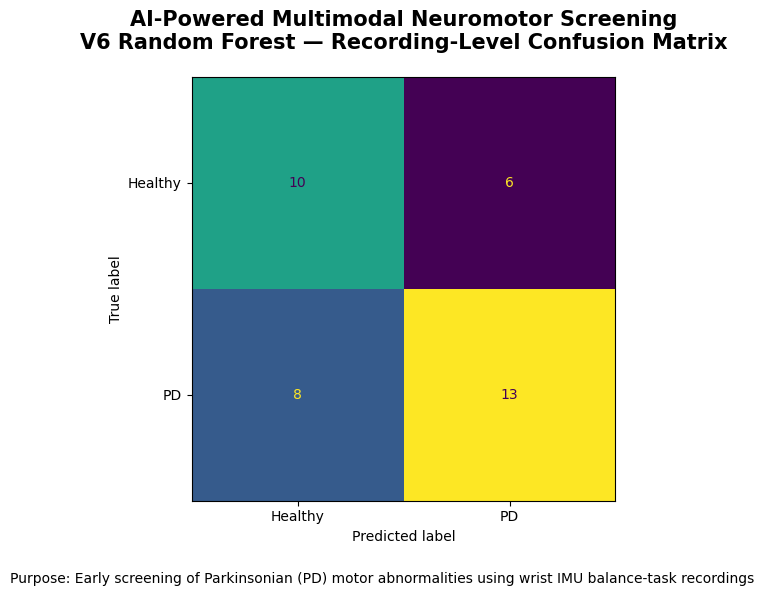

In [47]:
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(
    recording_results_v6["actual_label"],
    recording_results_v6["final_prediction"]
)

fig, ax = plt.subplots(figsize=(7, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Healthy", "PD"]
)

disp.plot(
    ax=ax,
    values_format="d",
    colorbar=False
)

ax.set_title(
    "AI-Powered Multimodal Neuromotor Screening\n"
    "V6 Random Forest — Recording-Level Confusion Matrix",
    fontsize=15,
    fontweight="bold",
    pad=20
)

fig.text(
    0.5,
    0.02,
    "Purpose: Early screening of Parkinsonian (PD) motor abnormalities "
    "using wrist IMU balance-task recordings",
    ha="center",
    fontsize=10
)

plt.tight_layout(rect=[0, 0.06, 1, 1])

plt.savefig(
    "V6_Confusion_Matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

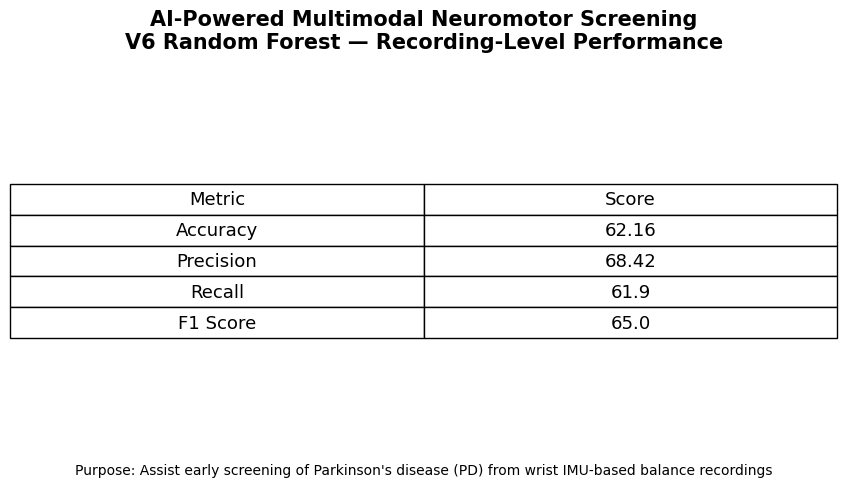

In [48]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

y_true = recording_results_v6["actual_label"]
y_pred = recording_results_v6["final_prediction"]

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

metrics_table = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "Score": [
        accuracy * 100,
        precision * 100,
        recall * 100,
        f1 * 100
    ]
})

metrics_table["Score"] = metrics_table["Score"].round(2)

fig, ax = plt.subplots(figsize=(9, 5))

ax.axis("off")

table = ax.table(
    cellText=metrics_table.values,
    colLabels=metrics_table.columns,
    cellLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(13)
table.scale(1.4, 2)

ax.set_title(
    "AI-Powered Multimodal Neuromotor Screening\n"
    "V6 Random Forest — Recording-Level Performance",
    fontsize=15,
    fontweight="bold",
    pad=25
)

fig.text(
    0.5,
    0.04,
    "Purpose: Assist early screening of Parkinson's disease (PD) "
    "from wrist IMU-based balance recordings",
    ha="center",
    fontsize=10
)

plt.tight_layout(rect=[0, 0.08, 1, 1])

plt.savefig(
    "V6_Performance_Metrics.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

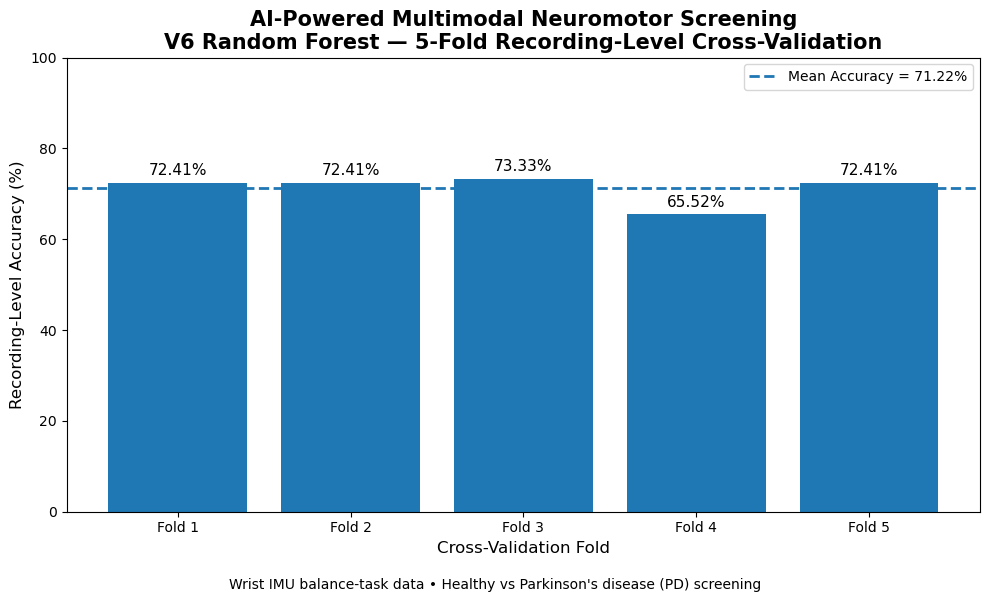

In [50]:
import matplotlib.pyplot as plt
import numpy as np

# Convert CV scores to percentages
cv_percent = np.array(fold_scores_v6) * 100

# Mean and standard deviation
cv_mean = cv_percent.mean()
cv_std = cv_percent.std()

# Create figure
fig, ax = plt.subplots(figsize=(10, 6))

# Plot fold accuracies
bars = ax.bar(
    ["Fold 1", "Fold 2", "Fold 3", "Fold 4", "Fold 5"],
    cv_percent
)

# Add mean line
ax.axhline(
    cv_mean,
    linestyle="--",
    linewidth=2,
    label=f"Mean Accuracy = {cv_mean:.2f}%"
)

# Add values on top of bars
for bar, value in zip(bars, cv_percent):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1,
        f"{value:.2f}%",
        ha="center",
        va="bottom",
        fontsize=11
    )

# Formatting
ax.set_ylim(0, 100)

ax.set_xlabel(
    "Cross-Validation Fold",
    fontsize=12
)

ax.set_ylabel(
    "Recording-Level Accuracy (%)",
    fontsize=12
)

ax.set_title(
    "AI-Powered Multimodal Neuromotor Screening\n"
    "V6 Random Forest — 5-Fold Recording-Level Cross-Validation",
    fontsize=15,
    fontweight="bold"
)

ax.legend()

fig.text(
    0.5,
    0.01,
    "Wrist IMU balance-task data • Healthy vs Parkinson's disease (PD) screening",
    ha="center",
    fontsize=10
)

plt.tight_layout(rect=[0, 0.04, 1, 1])

plt.savefig(
    "V6_CV_Accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [51]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)
import pandas as pd

y_true = recording_results_v6["actual_label"]
y_pred = recording_results_v6["final_prediction"]

# Overall metrics
accuracy = accuracy_score(y_true, y_pred)

# Classification report as dictionary
report = classification_report(
    y_true,
    y_pred,
    target_names=["Healthy", "PD"],
    output_dict=True
)

# Create clean table
metrics_table = pd.DataFrame({
    "Class": ["Healthy", "PD", "Overall"],
    "Precision": [
        report["Healthy"]["precision"],
        report["PD"]["precision"],
        report["weighted avg"]["precision"]
    ],
    "Recall": [
        report["Healthy"]["recall"],
        report["PD"]["recall"],
        report["weighted avg"]["recall"]
    ],
    "F1-Score": [
        report["Healthy"]["f1-score"],
        report["PD"]["f1-score"],
        report["weighted avg"]["f1-score"]
    ],
    "Support": [
        int(report["Healthy"]["support"]),
        int(report["PD"]["support"]),
        int(report["weighted avg"]["support"])
    ]
})

# Convert scores to percentages
for col in ["Precision", "Recall", "F1-Score"]:
    metrics_table[col] = (
        metrics_table[col] * 100
    ).round(2)

print("V6 Recording-Level Performance")
print("=" * 45)
print(f"Accuracy: {accuracy * 100:.2f}%")
print()

display(metrics_table)

V6 Recording-Level Performance
Accuracy: 62.16%



,Class,Precision,Recall,F1-Score,Support
0,Healthy,55.56,62.50,58.82,16
1,PD,68.42,61.90,65.00,21
2,Overall,62.86,62.16,62.33,37


In [52]:
print("V6 Feature Columns:")
print("=" * 60)

for i, col in enumerate(v6_feature_cols, start=1):
    print(f"{i:2d}. {col}")

print("=" * 60)
print("Total V6 features:", len(v6_feature_cols))

V6 Feature Columns:
 1. R_Wrist_Acc_X_mean
 2. R_Wrist_Acc_X_std
 3. R_Wrist_Acc_X_min
 4. R_Wrist_Acc_X_max
 5. R_Wrist_Acc_X_rms
 6. R_Wrist_Acc_Y_mean
 7. R_Wrist_Acc_Y_std
 8. R_Wrist_Acc_Y_min
 9. R_Wrist_Acc_Y_max
10. R_Wrist_Acc_Y_rms
11. R_Wrist_Acc_Z_mean
12. R_Wrist_Acc_Z_std
13. R_Wrist_Acc_Z_min
14. R_Wrist_Acc_Z_max
15. R_Wrist_Acc_Z_rms
16. R_Wrist_Acc_Y_mean_abs_change
17. R_Wrist_Acc_Y_zero_crossing_rate
18. R_Wrist_Acc_Z_mean_abs_change
19. Acc_Magnitude_mean
20. Acc_Magnitude_rms
21. Acc_Magnitude_mean_abs_change
Total V6 features: 21


In [53]:
print("BALANCE V6 - FEATURE EXTRACTION")
print("=" * 70)

raw_balance_cols = [
    "R_Wrist_Acc_X",
    "R_Wrist_Acc_Y",
    "R_Wrist_Acc_Z",
    "R_Wrist_Gyr_X",
    "R_Wrist_Gyr_Y",
    "R_Wrist_Gyr_Z"
]

print("\nRAW SENSOR COLUMNS:")
for i, col in enumerate(raw_balance_cols, 1):
    print(f"{i}. {col}")

print("\nFEATURES EXTRACTED FROM EACH RAW SIGNAL:")
for col in raw_balance_cols:
    print(f"\n{col}:")
    print(f"  - {col}_mean")
    print(f"  - {col}_std")
    print(f"  - {col}_min")
    print(f"  - {col}_max")
    print(f"  - {col}_rms")

print("\nDERIVED MAGNITUDE FEATURES:")
print("  - Acc_Magnitude_mean")
print("  - Acc_Magnitude_std")
print("  - Acc_Magnitude_min")
print("  - Acc_Magnitude_max")
print("  - Acc_Magnitude_rms")

print("  - Gyr_Magnitude_mean")
print("  - Gyr_Magnitude_std")
print("  - Gyr_Magnitude_min")
print("  - Gyr_Magnitude_max")
print("  - Gyr_Magnitude_rms")

BALANCE V6 - FEATURE EXTRACTION

RAW SENSOR COLUMNS:
1. R_Wrist_Acc_X
2. R_Wrist_Acc_Y
3. R_Wrist_Acc_Z
4. R_Wrist_Gyr_X
5. R_Wrist_Gyr_Y
6. R_Wrist_Gyr_Z

FEATURES EXTRACTED FROM EACH RAW SIGNAL:

R_Wrist_Acc_X:
  - R_Wrist_Acc_X_mean
  - R_Wrist_Acc_X_std
  - R_Wrist_Acc_X_min
  - R_Wrist_Acc_X_max
  - R_Wrist_Acc_X_rms

R_Wrist_Acc_Y:
  - R_Wrist_Acc_Y_mean
  - R_Wrist_Acc_Y_std
  - R_Wrist_Acc_Y_min
  - R_Wrist_Acc_Y_max
  - R_Wrist_Acc_Y_rms

R_Wrist_Acc_Z:
  - R_Wrist_Acc_Z_mean
  - R_Wrist_Acc_Z_std
  - R_Wrist_Acc_Z_min
  - R_Wrist_Acc_Z_max
  - R_Wrist_Acc_Z_rms

R_Wrist_Gyr_X:
  - R_Wrist_Gyr_X_mean
  - R_Wrist_Gyr_X_std
  - R_Wrist_Gyr_X_min
  - R_Wrist_Gyr_X_max
  - R_Wrist_Gyr_X_rms

R_Wrist_Gyr_Y:
  - R_Wrist_Gyr_Y_mean
  - R_Wrist_Gyr_Y_std
  - R_Wrist_Gyr_Y_min
  - R_Wrist_Gyr_Y_max
  - R_Wrist_Gyr_Y_rms

R_Wrist_Gyr_Z:
  - R_Wrist_Gyr_Z_mean
  - R_Wrist_Gyr_Z_std
  - R_Wrist_Gyr_Z_min
  - R_Wrist_Gyr_Z_max
  - R_Wrist_Gyr_Z_rms

DERIVED MAGNITUDE FEATURES:
  - Acc_Magn